← [Motor de inferencia](05-motor-de-inferencia.ipynb) · [Índice](00-indice.ipynb) · Siguiente: [Transfer learning y MobileNet](07-transfer-learning-y-mobilenet.ipynb) →

# 06 · Redes neuronales



## Estado vigente del proyecto (actualizado el 13 de agosto de 2026)

Esta serie conserva explicaciones y resultados históricos, pero la referencia
operativa actual es la siguiente:

- El sistema experto tiene **193 reglas**, CF estilo MYCIN, meta-reglas,
  encadenamiento hacia adelante y hacia atrás. Su voto usa OpenAI como
  proveedor principal, con heurísticas OpenCV que refinan atributos.
- El modelo local que participa en la decisión es **MobileNetV2 TFLite
  float32**, corrida `run_20260721_2129`; clasifica solo `plastico | vidrio`.
  MobileNetV3-Large INT8 está archivado como respaldo y **no emite votos**.
- En 1.000 capturas OV3660/QVGA, V2 obtuvo **71,60 %** de exactitud y
  **71,25 %** de macro-F1; V3 INT8 obtuvo 57,10 % y 57,09 %. La validación
  histórica de 98,43 % no describe por sí sola el rendimiento del robot.
- La ESP32-CAM toma tres fotos: se suman los seis votos válidos de ambas
  fuentes. `desconocido` es abstención; un empate se resuelve con el proveedor.
  Si el proveedor se abstiene las tres veces, el modelo local necesita 3/3.

La documentación operativa es [`ia/vision-service/README.md`](../../ia/vision-service/README.md),
[`model/README.md`](../../ia/vision-service/model/README.md) y
[`PLAN-INTEGRACION-VISION-MAIN-2026-08-13.md`](../../docs/PLAN-INTEGRACION-VISION-MAIN-2026-08-13.md).


## Qué es una imagen para una computadora

Una foto de la ESP32-CAM es una cuadrícula de números:

```
320 × 240 píxeles × 3 canales (rojo, verde, azul)  =  230.400 números
```

Cada número va de 0 a 255. No hay "botella" en ninguna parte: solo intensidades.
Todo el trabajo consiste en pasar de esos 230.400 números a **dos**: qué tan
plástico y qué tan vidrio.



## El problema de la fuerza bruta

Se podría conectar cada píxel a una red que aprenda directamente. No funciona,
por dos razones:

**Demasiados parámetros.** Conectar 230.400 entradas a mil neuronas son 230
millones de pesos solo en la primera capa. Imposible de entrenar con 26.000
fotos.

**No generaliza en el espacio.** Una red así aprendería "hay una tapa metálica
en la esquina superior izquierda". Si el objeto aparece cinco centímetros a la
derecha, todo lo aprendido deja de servir.



## La convolución

La solución es no mirar la imagen entera de golpe, sino pasar una **ventana
pequeña** por toda ella, buscando siempre el mismo patrón.

```
imagen completa            ventana 3×3 que recorre toda la imagen
┌─────────────────┐        ┌───┐
│                 │        │▓▓▓│  detecta, por ejemplo,
│      ▓▓▓        │   ←    │▓▓▓│  un borde vertical
│                 │        │▓▓▓│
└─────────────────┘        └───┘
```

Dos consecuencias, y ambas resuelven un problema de arriba:

1. **Pocos parámetros.** La ventana son 9 números reutilizados en toda la
   imagen, no 230.400 distintos.
2. **Invariancia a la posición.** Si el patrón aparece en cualquier lugar, la
   misma ventana lo encuentra. Da igual dónde esté la botella.

Eso es una **convolución**, y una red que las apila es una **red neuronal
convolucional** (CNN).



## Las capas y la jerarquía

Una CNN apila muchas convoluciones. Lo interesante es que cada nivel detecta
cosas más complejas que el anterior, **sin que nadie lo programe**:

| Nivel | Qué detecta |
| --- | --- |
| Primeras capas | Bordes, cambios de color, esquinas |
| Capas medias | Curvas, texturas, brillos, patrones repetidos |
| Capas profundas | Partes de objetos: un cuello de botella, una tapa |
| Última capa | El objeto completo |

Esta jerarquía **emerge** del entrenamiento. Es el contraste más fuerte con el
sistema experto, donde alguien escribió a mano que la tapa corona indica vidrio.



## Cómo aprende

El entrenamiento es un ciclo repetido millones de veces:

```
1. mostrar una foto        →  la red predice "plástico 0,7 / vidrio 0,3"
2. comparar con la verdad  →  era vidrio: error alto
3. calcular la culpa       →  ¿qué parámetro contribuyó y cuánto?  (backpropagation)
4. ajustar un poquito      →  cada parámetro se mueve en la dirección que reduce el error
5. repetir
```

El paso 4 es clave: los ajustes son **pequeños**. Una sola foto no cambia mucho
la red; lo que la moldea es la repetición sobre miles de ejemplos. De ahí que
haga falta tanto dato.

Dos términos que aparecen en los scripts de entrenamiento:

- **Época** (*epoch*): una pasada completa por todo el dataset. Las corridas de
  Reci pararon entre las épocas 12 y 27.
- **Lote** (*batch*): cuántas fotos se procesan antes de cada ajuste. En Reci,
  32 por defecto.



## Softmax: la salida

La última capa produce dos números que se normalizan para sumar 1:

```
{ "plastico": 0.23,  "vidrio": 0.77 }   ←  siempre suman 1,0
```

Gana el mayor, y su valor se reporta como "confianza".

**Aquí hay una trampa importante.** Que sumen 1 obliga a la red a repartir toda
la certeza entre las dos opciones que conoce. Si le muestras una lata, no puede
decir "ninguna de las dos": tiene que dar un número alto a alguna. Por eso el
modelo local clasificó un mango como plástico con confianza `1.0000`.

La confianza de la softmax **no mide si el modelo tiene razón**: mide cuán
desbalanceado quedó el reparto interno. Un modelo puede estar completamente
equivocado y muy "confiado" a la vez — y en Reci ocurrió: 17 de 25 errores de
vidrio tuvieron confianza ≥ 0,90.

Compáralo con el factor de certeza del documento [04](04-factor-de-certeza.ipynb),
que por construcción nunca alcanza 1,0 y donde cada categoría acumula su
evidencia por separado.



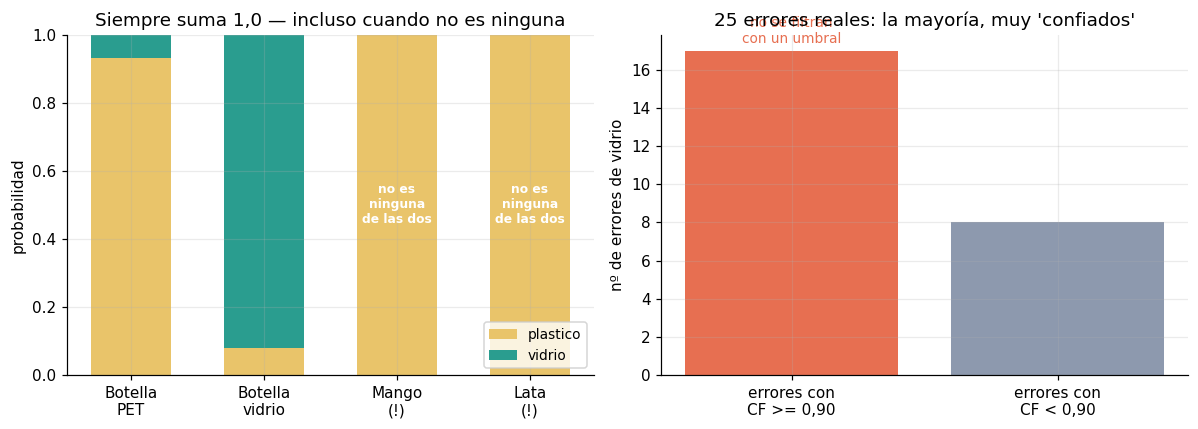

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

VIDRIO, PLASTICO, GRIS, ALERTA = "#2a9d8f", "#e9c46a", "#8d99ae", "#e76f51"
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 10, "axes.grid": True,
    "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False,
})

# La softmax siempre reparte 1,0 entre las clases que conoce
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

casos = ["Botella\nPET", "Botella\nvidrio", "Mango\n(!)", "Lata\n(!)"]
plastico = [0.93, 0.08, 1.00, 0.9998]
vidrio = [1 - p for p in plastico]
x = np.arange(len(casos))
ax1.bar(x, plastico, 0.6, label="plastico", color=PLASTICO)
ax1.bar(x, vidrio, 0.6, bottom=plastico, label="vidrio", color=VIDRIO)
ax1.set_xticks(x); ax1.set_xticklabels(casos)
ax1.set(ylabel="probabilidad", ylim=(0, 1),
        title="Siempre suma 1,0 — incluso cuando no es ninguna")
ax1.legend(loc="lower right", fontsize=9)
for i in (2, 3):
    ax1.text(i, 0.5, "no es\nninguna\nde las dos", ha="center", va="center",
             fontsize=8, color="white", weight="bold")

# Confianza declarada frente a si acertó (evaluación de webcam)
ax2.bar(["errores con\nCF >= 0,90", "errores con\nCF < 0,90"], [17, 8],
        color=[ALERTA, GRIS])
ax2.set(ylabel="nº de errores de vidrio",
        title="25 errores reales: la mayoría, muy 'confiados'")
ax2.text(0, 17.4, "no se filtran\ncon un umbral", ha="center", fontsize=9, color=ALERTA)

plt.tight_layout(); plt.show()

## Lo que sigue

Entrenar una CNN desde cero exige millones de imágenes. Reci tenía 26.000. El
siguiente documento explica cómo se resuelve eso.

---

← [Motor de inferencia](05-motor-de-inferencia.ipynb) · [Índice](00-indice.ipynb) · Siguiente: [Transfer learning y MobileNet](07-transfer-learning-y-mobilenet.ipynb) →
